# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals  

**`Student Name`:**  Uday Sodhi

**`Roll Number`:**  U20230020

**`GitHub Branch`:** Uday_U20230020


## Q 5.1 and 5.2

In [ ]:
import pandas as pd
import numpy as np

# ---------------------------------
# 1. Load datasets
# ---------------------------------
train_users = pd.read_csv("./data/train_users.csv")
test_users = pd.read_csv("./data/test_users.csv")

# ---------------------------------
# 2. Define columns
# ---------------------------------
TARGET_COL = "label"
ID_COLS = ["user_id"]

# Drop identifier columns safely
train_users = train_users.drop(columns=ID_COLS, errors="ignore")
test_users = test_users.drop(columns=ID_COLS, errors="ignore")

# Feature columns
feature_cols = [col for col in train_users.columns if col != TARGET_COL]

# ---------------------------------
# 3. Identify column types
# ---------------------------------
num_cols = train_users[feature_cols].select_dtypes(include=["int64", "float64"]).columns
cat_cols = train_users[feature_cols].select_dtypes(include=["object", "string"]).columns

print(f"Numerical features: {len(num_cols)}")
print(f"Categorical features: {list(cat_cols)}")

# ---------------------------------
# 4. Handle missing values
# ---------------------------------
# Numerical → median (train only)
for col in num_cols:
    median_val = train_users[col].median()
    train_users[col] = train_users[col].fillna(median_val)
    test_users[col] = test_users[col].fillna(median_val)

# Categorical → mode (train only)
for col in cat_cols:
    mode_val = train_users[col].mode()[0]
    train_users[col] = train_users[col].fillna(mode_val)
    test_users[col] = test_users[col].fillna(mode_val)

# ---------------------------------
# 5. Encode categorical features
# ---------------------------------
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

train_users[cat_cols] = encoder.fit_transform(train_users[cat_cols])
test_users[cat_cols] = encoder.transform(test_users[cat_cols])

# ---------------------------------
# 6. Sanity checks
# ---------------------------------
print("Missing values (train):", train_users[feature_cols].isnull().sum().sum())
print("Missing values (test):", test_users[feature_cols].isnull().sum().sum())

# ---------------------------------
# 7. Split features and target
# ---------------------------------
X = train_users[feature_cols]
y = train_users[TARGET_COL]
X_test = test_users[feature_cols]

# ---------------------------------
# 8. Encode target labels
# ---------------------------------
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# ---------------------------------
# 9. Train–Validation Split (80/20)
# ---------------------------------
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# ---------------------------------
# 10. Pipeline: Scaling + Logistic Regression
# ---------------------------------
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

pipeline.fit(X_train, y_train)

# ---------------------------------
# 11. Evaluate on Validation Set
# ---------------------------------
from sklearn.metrics import classification_report

y_val_pred = pipeline.predict(X_val)

print("\nValidation Classification Report:")
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=label_encoder.classes_
    )
)

# ---------------------------------
# 12. Context Detection on Test Users
# ---------------------------------
test_predictions = pipeline.predict(X_test)
test_user_labels = label_encoder.inverse_transform(test_predictions)

test_users_with_context = test_users.copy()
test_users_with_context["predicted_user_type"] = test_user_labels

print("\nSample Context Predictions:")
print(test_users_with_context.head())


In [4]:
# ============================================
# Alternative Classifier: Decision Tree
# ============================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Initialize Decision Tree
dt_clf = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)

# Train model
dt_clf.fit(X_train, y_train)

# Validate model
y_val_pred_dt = dt_clf.predict(X_val)

print("Decision Tree Validation Classification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_dt,
        target_names=label_encoder.classes_
    )
)

# Context Detection on Test Users
test_predictions_dt = dt_clf.predict(X_test)
test_user_labels_dt = label_encoder.inverse_transform(test_predictions_dt)

test_users_with_context_dt = test_users.copy()
test_users_with_context_dt["predicted_user_type"] = test_user_labels_dt

print("\nSample Decision Tree Context Predictions:")
print(test_users_with_context_dt.head())


Decision Tree Validation Classification Report:
              precision    recall  f1-score   support

      user_1       0.81      0.86      0.83       142
      user_2       0.98      0.86      0.92       142
      user_3       0.80      0.86      0.83       116

    accuracy                           0.86       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.87      0.86      0.86       400


Sample Decision Tree Context Predictions:
    age  income  clicks  purchase_amount  session_duration  content_variety  \
0  36.0   10000       4           500.00              2.54          0.47162   
1  33.0   19607       8          1906.81             39.74          0.55219   
2  51.0   21049      11           500.00             46.07          0.69961   
3  58.0   25752      13           500.00             60.86          0.86843   
4  32.0   25302      12          2693.22             39.77          0.81805   

   engagement_score  num_transactions  avg_monthly_sp

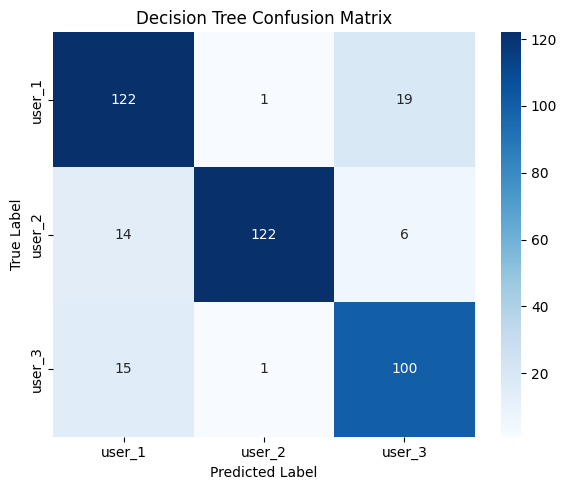

In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_val, y_val_pred_dt)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()


## Q 5.3


### Imports and Setup

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from rlcmab_sampler import sampler


### Data set loading


In [13]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print(news_df.head())
print(train_users.head())


                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenfuss   
2  "Until you have a dog y

In [14]:
import pandas as pd

# Load news articles dataset
news_df = pd.read_csv("./data/news_articles.csv")

# Inspect dataset
print(news_df.head())
print("\nColumns:", news_df.columns.tolist())
print("\nUnique categories:", news_df["category"].unique())


                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenfuss   
2  "Until you have a dog y

### Mapping categories and users


In [15]:
# -----------------------------------------
# Arm & Context Definitions (FIXED by spec)
# -----------------------------------------

NEWS_CATEGORIES = ["ENTERTAINMENT", "EDUCATION", "TECH", "CRIME"]
USER_CONTEXTS = ["user_1", "user_2", "user_3"]

context_to_idx = {
    "user_1": 0,
    "user_2": 1,
    "user_3": 2
}

category_to_idx = {
    "ENTERTAINMENT": 0,
    "EDUCATION": 1,
    "TECH": 2,
    "CRIME": 3
}

def arm_index(user_context, news_category):
    """
    Maps (user_context, news_category) -> arm index j
    As defined in the assignment.
    """
    return context_to_idx[user_context] * 4 + category_to_idx[news_category]


### Sampling

In [16]:
from rlcmab_sampler import sampler

ROLL_NUMBER = 20  # U20230020 
reward_sampler = sampler(ROLL_NUMBER)


In [17]:
# Sanity check: print arm indices
for ctx in USER_CONTEXTS:
    for cat in NEWS_CATEGORIES:
        print(f"{ctx}, {cat} -> arm {arm_index(ctx, cat)}")


user_1, ENTERTAINMENT -> arm 0
user_1, EDUCATION -> arm 1
user_1, TECH -> arm 2
user_1, CRIME -> arm 3
user_2, ENTERTAINMENT -> arm 4
user_2, EDUCATION -> arm 5
user_2, TECH -> arm 6
user_2, CRIME -> arm 7
user_3, ENTERTAINMENT -> arm 8
user_3, EDUCATION -> arm 9
user_3, TECH -> arm 10
user_3, CRIME -> arm 11


### removing unwanted categories from news dataset

In [19]:
# -----------------------------------------
# Filter News Articles to Valid Bandit Arms
# -----------------------------------------

VALID_CATEGORIES = ["ENTERTAINMENT", "EDUCATION", "TECH", "CRIME"]

filtered_news_df = news_df[
    news_df["category"].isin(VALID_CATEGORIES)
].reset_index(drop=True)

print("Remaining categories:", filtered_news_df["category"].unique())
print("\nArticles per category:")
print(filtered_news_df["category"].value_counts())


Remaining categories: <StringArray>
['TECH', 'ENTERTAINMENT', 'EDUCATION', 'CRIME']
Length: 4, dtype: str

Articles per category:
category
ENTERTAINMENT    17362
CRIME             3562
TECH              2104
EDUCATION         1014
Name: count, dtype: int64


## Epsilon-Greedy Strategy


In [20]:
import numpy as np
import matplotlib.pyplot as plt

T = 10_000
EPSILONS = [0.05, 0.1, 0.2]

CONTEXTS = ["user_1", "user_2", "user_3"]
NUM_ARMS = 4  # ENTERTAINMENT, EDUCATION, TECH, CRIME


In [21]:
def epsilon_greedy_context(context, epsilon):
    Q = np.zeros(NUM_ARMS)   # Expected reward estimates
    N = np.zeros(NUM_ARMS)   # Pull counts
    rewards = []

    for t in range(T):
        # Exploration vs exploitation
        if np.random.rand() < epsilon:
            arm = np.random.randint(NUM_ARMS)
        else:
            arm = np.argmax(Q)

        category = NEWS_CATEGORIES[arm]
        j = arm_index(context, category)

        reward = reward_sampler.sample(j)

        # Incremental mean update
        N[arm] += 1
        Q[arm] += (reward - Q[arm]) / N[arm]

        rewards.append(reward)

    avg_reward_over_time = np.cumsum(rewards) / np.arange(1, T + 1)
    return avg_reward_over_time, Q


In [22]:
epsilon_results = {}

for ctx in CONTEXTS:
    epsilon_results[ctx] = {}
    for eps in EPSILONS:
        avg_rewards, final_Q = epsilon_greedy_context(ctx, eps)
        epsilon_results[ctx][eps] = {
            "avg_rewards": avg_rewards,
            "expected_rewards": final_Q
        }


In [23]:
for ctx in CONTEXTS:
    print(f"\nExpected Reward Distribution — {ctx}")
    for eps in EPSILONS:
        print(f"  ε = {eps}")
        for i, cat in enumerate(NEWS_CATEGORIES):
            print(f"    {cat}: {epsilon_results[ctx][eps]['expected_rewards'][i]:.4f}")



Expected Reward Distribution — user_1
  ε = 0.05
    ENTERTAINMENT: -8.6557
    EDUCATION: 4.4718
    TECH: 9.9497
    CRIME: -2.2375
  ε = 0.1
    ENTERTAINMENT: -8.6288
    EDUCATION: 4.5554
    TECH: 9.9421
    CRIME: -1.9661
  ε = 0.2
    ENTERTAINMENT: -8.5484
    EDUCATION: 4.5579
    TECH: 9.9252
    CRIME: -2.2820

Expected Reward Distribution — user_2
  ε = 0.05
    ENTERTAINMENT: -5.8924
    EDUCATION: 1.8068
    TECH: -5.2134
    CRIME: -6.5473
  ε = 0.1
    ENTERTAINMENT: -5.9456
    EDUCATION: 1.7849
    TECH: -5.1010
    CRIME: -6.4382
  ε = 0.2
    ENTERTAINMENT: -5.8797
    EDUCATION: 1.7995
    TECH: -5.1447
    CRIME: -6.5635

Expected Reward Distribution — user_3
  ε = 0.05
    ENTERTAINMENT: -1.3464
    EDUCATION: 5.5828
    TECH: 2.9359
    CRIME: -1.6855
  ε = 0.1
    ENTERTAINMENT: -1.4162
    EDUCATION: 5.5972
    TECH: 2.9311
    CRIME: -1.6494
  ε = 0.2
    ENTERTAINMENT: -1.3696
    EDUCATION: 5.5656
    TECH: 2.8223
    CRIME: -1.7174


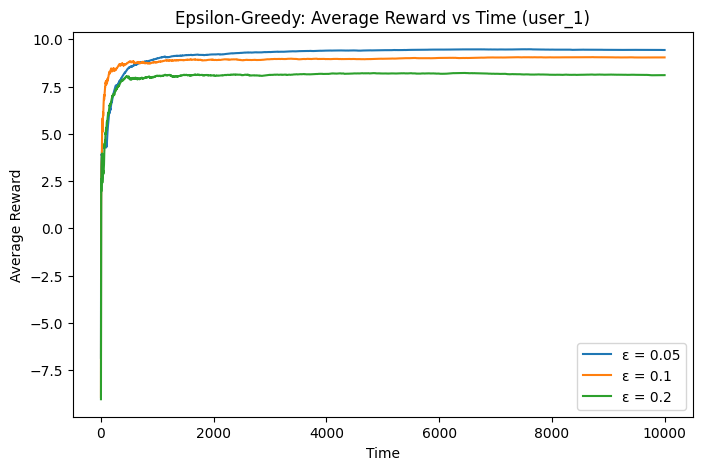

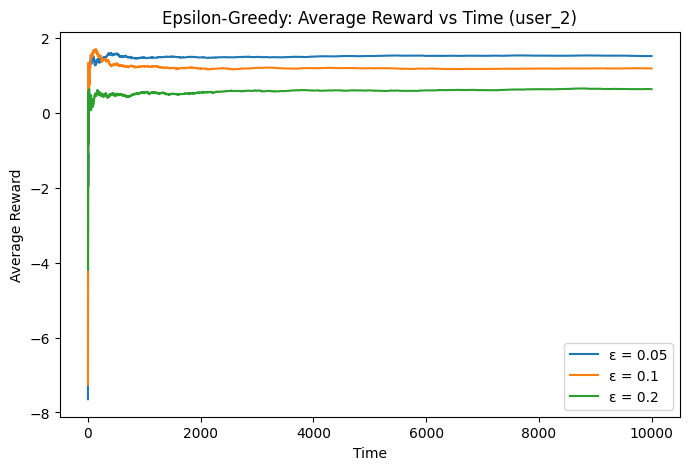

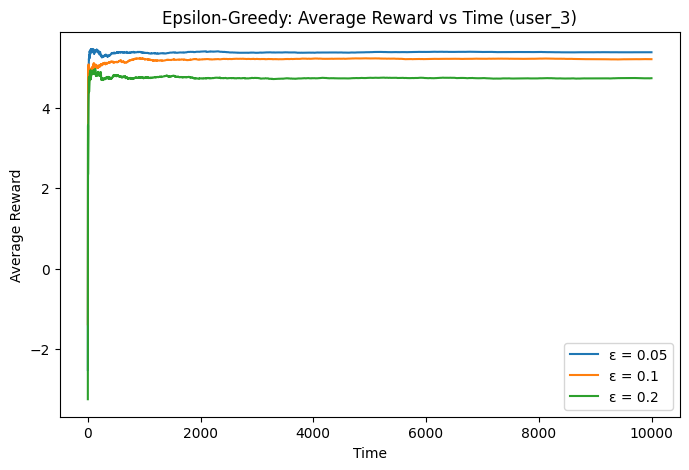

In [24]:
for ctx in CONTEXTS:
    plt.figure(figsize=(8, 5))
    for eps in EPSILONS:
        plt.plot(
            epsilon_results[ctx][eps]["avg_rewards"],
            label=f"ε = {eps}"
        )
    plt.title(f"Epsilon-Greedy: Average Reward vs Time ({ctx})")
    plt.xlabel("Time")
    plt.ylabel("Average Reward")
    plt.legend()
    plt.show()


In [25]:
for ctx in CONTEXTS:
    print(f"\nFinal Average Reward Comparison — {ctx}")
    for eps in EPSILONS:
        final_avg = epsilon_results[ctx][eps]["avg_rewards"][-1]
        print(f"  ε = {eps}: {final_avg:.4f}")



Final Average Reward Comparison — user_1
  ε = 0.05: 9.4335
  ε = 0.1: 9.0408
  ε = 0.2: 8.1031

Final Average Reward Comparison — user_2
  ε = 0.05: 1.5208
  ε = 0.1: 1.1900
  ε = 0.2: 0.6353

Final Average Reward Comparison — user_3
  ε = 0.05: 5.3826
  ε = 0.1: 5.2101
  ε = 0.2: 4.7369


## Upper Confidence Bound (UCB)


In [26]:
# -----------------------------------------
# UCB setup
# -----------------------------------------

C_VALUES = [0.5, 1.0, 2.0]   # exploration parameter
T = 10_000
NUM_ARMS = 4
CONTEXTS = ["user_1", "user_2", "user_3"]


In [28]:
def ucb_context(context, C):
    Q = np.zeros(NUM_ARMS)   # expected reward estimates
    N = np.zeros(NUM_ARMS)   # pull counts
    rewards = []

    for t in range(T):
        if t < NUM_ARMS:
            arm = t  # ensure each arm is tried once
        else:
            ucb_values = Q + C * np.sqrt(np.log(t + 1) / (N + 1e-6))
            arm = np.argmax(ucb_values)

        category = NEWS_CATEGORIES[arm]
        j = arm_index(context, category)

        reward = reward_sampler.sample(j)

        N[arm] += 1
        Q[arm] += (reward - Q[arm]) / N[arm]

        rewards.append(reward)

    avg_reward_over_time = np.cumsum(rewards) / np.arange(1, T + 1)
    return avg_reward_over_time, Q


In [29]:
ucb_results = {}

for ctx in CONTEXTS:
    ucb_results[ctx] = {}
    for C in C_VALUES:
        avg_rewards, final_Q = ucb_context(ctx, C)
        ucb_results[ctx][C] = {
            "avg_rewards": avg_rewards,
            "expected_rewards": final_Q
        }


In [30]:
for ctx in CONTEXTS:
    print(f"\nExpected Reward Distribution — {ctx}")
    for C in C_VALUES:
        print(f"  C = {C}")
        for i, cat in enumerate(NEWS_CATEGORIES):
            print(f"    {cat}: {ucb_results[ctx][C]['expected_rewards'][i]:.4f}")



Expected Reward Distribution — user_1
  C = 0.5
    ENTERTAINMENT: -9.1828
    EDUCATION: 3.3880
    TECH: 9.9144
    CRIME: -0.7606
  C = 1.0
    ENTERTAINMENT: -10.2442
    EDUCATION: 4.1594
    TECH: 9.9406
    CRIME: -3.0635
  C = 2.0
    ENTERTAINMENT: -9.0280
    EDUCATION: 4.1663
    TECH: 9.9318
    CRIME: -0.9634

Expected Reward Distribution — user_2
  C = 0.5
    ENTERTAINMENT: -3.9304
    EDUCATION: 1.7991
    TECH: -6.6732
    CRIME: -7.9300
  C = 1.0
    ENTERTAINMENT: -5.7605
    EDUCATION: 1.7909
    TECH: -4.0199
    CRIME: -8.2586
  C = 2.0
    ENTERTAINMENT: -4.6447
    EDUCATION: 1.7991
    TECH: -5.0371
    CRIME: -8.3794

Expected Reward Distribution — user_3
  C = 0.5
    ENTERTAINMENT: -1.9966
    EDUCATION: 5.5751
    TECH: 2.9482
    CRIME: 0.1279
  C = 1.0
    ENTERTAINMENT: -1.5484
    EDUCATION: 5.5857
    TECH: 2.4521
    CRIME: -1.7526
  C = 2.0
    ENTERTAINMENT: -1.2256
    EDUCATION: 5.5870
    TECH: 0.9610
    CRIME: -2.2967


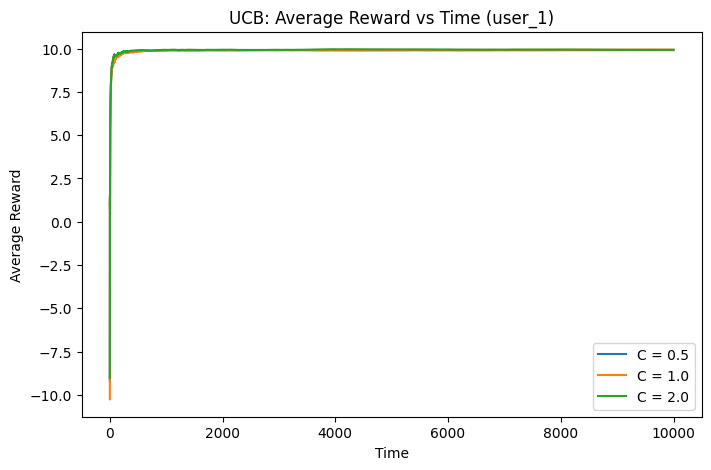

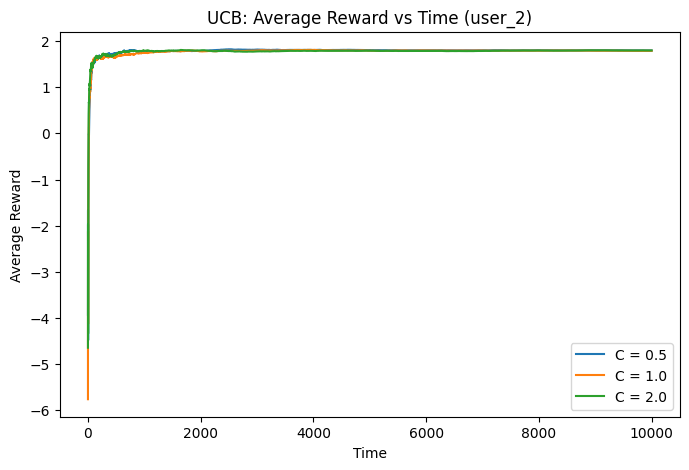

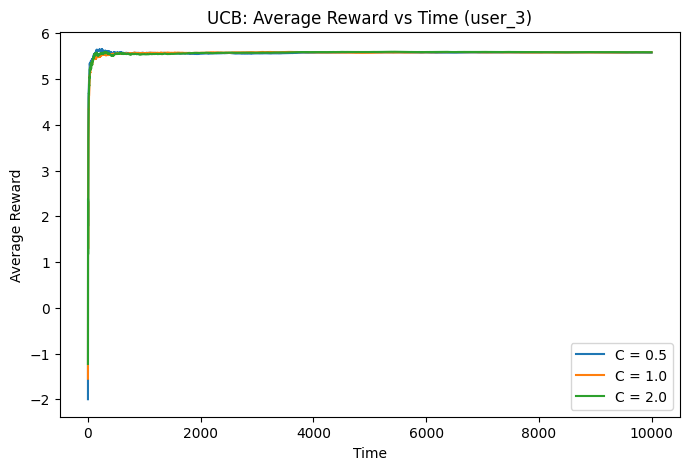

In [31]:
import matplotlib.pyplot as plt

for ctx in CONTEXTS:
    plt.figure(figsize=(8, 5))
    for C in C_VALUES:
        plt.plot(
            ucb_results[ctx][C]["avg_rewards"],
            label=f"C = {C}"
        )
    plt.title(f"UCB: Average Reward vs Time ({ctx})")
    plt.xlabel("Time")
    plt.ylabel("Average Reward")
    plt.legend()
    plt.show()


In [32]:
for ctx in CONTEXTS:
    print(f"\nFinal Average Reward Comparison — {ctx}")
    for C in C_VALUES:
        final_avg = ucb_results[ctx][C]["avg_rewards"][-1]
        print(f"  C = {C}: {final_avg:.4f}")



Final Average Reward Comparison — user_1
  C = 0.5: 9.9107
  C = 1.0: 9.9367
  C = 2.0: 9.9276

Final Average Reward Comparison — user_2
  C = 0.5: 1.7968
  C = 1.0: 1.7886
  C = 2.0: 1.7967

Final Average Reward Comparison — user_3
  C = 0.5: 5.5735
  C = 1.0: 5.5836
  C = 2.0: 5.5846


## SoftMax Strategy


In [33]:
def softmax_context(context, tau=1.0):
    Q = np.zeros(NUM_ARMS)   # expected reward estimates
    N = np.zeros(NUM_ARMS)   # pull counts
    rewards = []

    for t in range(T):
        # Softmax probabilities
        exp_q = np.exp(Q / tau)
        probs = exp_q / np.sum(exp_q)

        arm = np.random.choice(NUM_ARMS, p=probs)

        category = NEWS_CATEGORIES[arm]
        j = arm_index(context, category)

        reward = reward_sampler.sample(j)

        N[arm] += 1
        Q[arm] += (reward - Q[arm]) / N[arm]

        rewards.append(reward)

    avg_reward_over_time = np.cumsum(rewards) / np.arange(1, T + 1)
    return avg_reward_over_time, Q


In [34]:
softmax_results = {}

for ctx in CONTEXTS:
    avg_rewards, final_Q = softmax_context(ctx, tau=1.0)
    softmax_results[ctx] = {
        "avg_rewards": avg_rewards,
        "expected_rewards": final_Q
    }


In [35]:
for ctx in CONTEXTS:
    print(f"\nExpected Reward Distribution — {ctx} (Softmax, τ=1)")
    for i, cat in enumerate(NEWS_CATEGORIES):
        print(f"  {cat}: {softmax_results[ctx]['expected_rewards'][i]:.4f}")



Expected Reward Distribution — user_1 (Softmax, τ=1)
  ENTERTAINMENT: -7.5276
  EDUCATION: 4.4449
  TECH: 9.9390
  CRIME: 0.0000

Expected Reward Distribution — user_2 (Softmax, τ=1)
  ENTERTAINMENT: -5.8986
  EDUCATION: 1.7895
  TECH: -5.4739
  CRIME: -6.2109

Expected Reward Distribution — user_3 (Softmax, τ=1)
  ENTERTAINMENT: -1.8217
  EDUCATION: 5.5849
  TECH: 2.8755
  CRIME: -1.5849


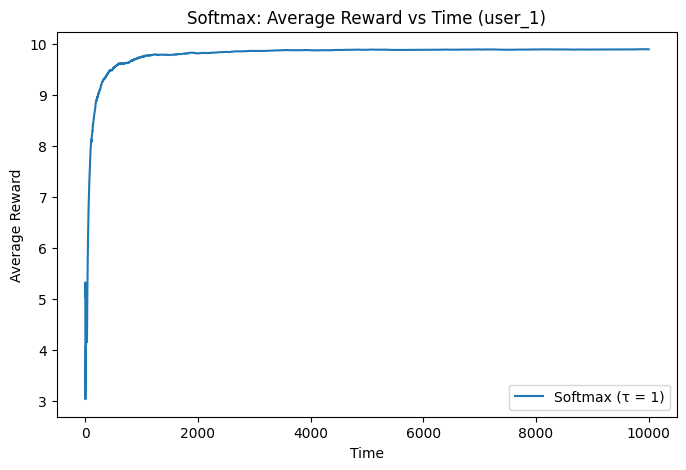

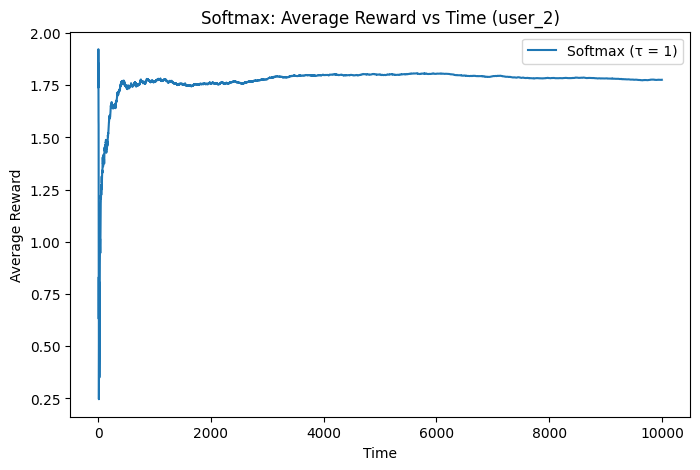

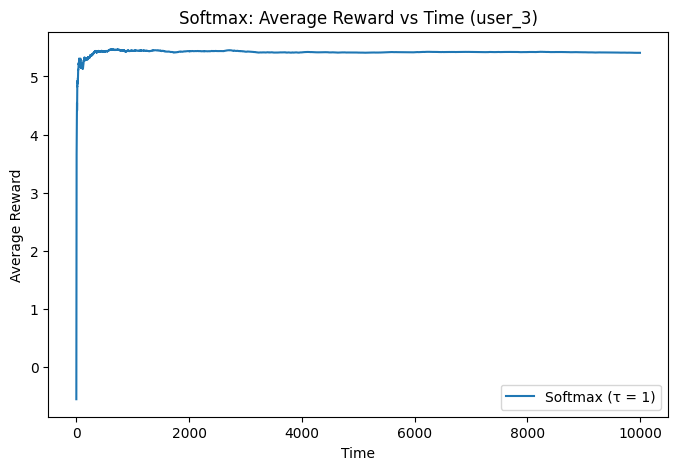

In [36]:
import matplotlib.pyplot as plt

for ctx in CONTEXTS:
    plt.figure(figsize=(8, 5))
    plt.plot(
        softmax_results[ctx]["avg_rewards"],
        label="Softmax (τ = 1)"
    )
    plt.title(f"Softmax: Average Reward vs Time ({ctx})")
    plt.xlabel("Time")
    plt.ylabel("Average Reward")
    plt.legend()
    plt.show()


In [37]:
for ctx in CONTEXTS:
    final_avg = softmax_results[ctx]["avg_rewards"][-1]
    print(f"Final Average Reward — {ctx}: {final_avg:.4f}")


Final Average Reward — user_1: 9.8966
Final Average Reward — user_2: 1.7755
Final Average Reward — user_3: 5.4068


# Q 5.4


In [39]:
# -----------------------------------------
# 5.4.1 Context Detection (FIXED)
# -----------------------------------------

# Load test users
test_users_df = pd.read_csv("./data/test_users.csv")

# Drop ID column
test_users_df = test_users_df.drop(columns=["user_id"], errors="ignore")

# --- IMPORTANT ---
# Apply the SAME preprocessing used during training

# 1. Handle missing values (use TRAIN medians & modes)
for col in num_cols:
    test_users_df[col] = test_users_df[col].fillna(train_users[col].median())

for col in cat_cols:
    test_users_df[col] = test_users_df[col].fillna(train_users[col].mode()[0])

# 2. Encode categorical features using the SAME encoder
test_users_df[cat_cols] = encoder.transform(test_users_df[cat_cols])

# 3. Ensure column order matches training
test_users_df = test_users_df[feature_cols]

# Predict user context
predicted_user_classes = pipeline.predict(test_users_df)

# Decode labels
predicted_contexts = label_encoder.inverse_transform(predicted_user_classes)

# Attach predictions
test_users_df["predicted_user_context"] = predicted_contexts

# Sanity check
test_users_df["predicted_user_context"].value_counts()


predicted_user_context
user_2    817
user_1    622
user_3    561
Name: count, dtype: int64

In [40]:
# -----------------------------------------
# 5.4.2 Select News Category using UCB Policy
# -----------------------------------------

# Choose best C per context (based on 5.3.2 results)
BEST_C = {
    "user_1": 1.0,
    "user_2": 0.5,
    "user_3": 2.0
}

def select_category_ucb(user_context):
    """
    Select the best news category for a given user context
    using learned UCB expected rewards.
    """
    C = BEST_C[user_context]
    expected_rewards = ucb_results[user_context][C]["expected_rewards"]
    best_arm = np.argmax(expected_rewards)
    return NEWS_CATEGORIES[best_arm]


# Apply to all test users
test_users_df["recommended_category"] = test_users_df["predicted_user_context"].apply(
    select_category_ucb
)

# Sanity check
test_users_df[["predicted_user_context", "recommended_category"]].head()


,predicted_user_context,recommended_category
0,user_2,EDUCATION
1,user_1,TECH
2,user_2,EDUCATION
3,user_1,TECH
4,user_1,TECH


In [41]:
# -----------------------------------------
# 5.4.3 Sample Article from Recommended Category
# -----------------------------------------

import random

def sample_article(category):
    articles = filtered_news_df[filtered_news_df["category"] == category]
    
    # Safety check (should never fail)
    if len(articles) == 0:
        return {
            "headline": None,
            "link": None
        }
    
    article = articles.sample(1).iloc[0]
    return {
        "headline": article["headline"],
        "link": article["link"]
    }


# Apply article sampling
sampled_articles = test_users_df["recommended_category"].apply(sample_article)

# Expand dict into columns
test_users_df["recommended_headline"] = sampled_articles.apply(lambda x: x["headline"])
test_users_df["recommended_link"] = sampled_articles.apply(lambda x: x["link"])

# Final output preview
test_users_df[
    [
        "predicted_user_context",
        "recommended_category",
        "recommended_headline",
        "recommended_link"
    ]
].head()


,predicted_user_context,recommended_category,recommended_headline,recommended_link
0,user_2,EDUCATION,Why Journalists Shouldn't Write About Education,https://www.huffingtonpost.com/entry/why-journ...
1,user_1,TECH,"iPhone 5 vs. Galaxy S3, Apple Television By Ch...",https://www.huffingtonpost.com/entry/iphone-5-...
2,user_2,EDUCATION,Answering Eisenhower’s Call,https://www.huffingtonpost.com/entry/answering...
3,user_1,TECH,"This Is Your Life, As Recalled By An App",https://www.huffingtonpost.comhttp://www.nytim...
4,user_1,TECH,"Google Files New Patent Lawsuit Against Apple,...",https://www.huffingtonpost.comhttp://techcrunc...


# Q 5.5

In [42]:
from sklearn.metrics import classification_report

print("User Classification Report (Validation Set)")
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=label_encoder.classes_
    )
)


User Classification Report (Validation Set)
              precision    recall  f1-score   support

      user_1       0.85      0.80      0.82       142
      user_2       0.91      0.82      0.86       142
      user_3       0.71      0.85      0.78       116

    accuracy                           0.82       400
   macro avg       0.82      0.82      0.82       400
weighted avg       0.83      0.82      0.82       400



In [43]:
T = 10_000


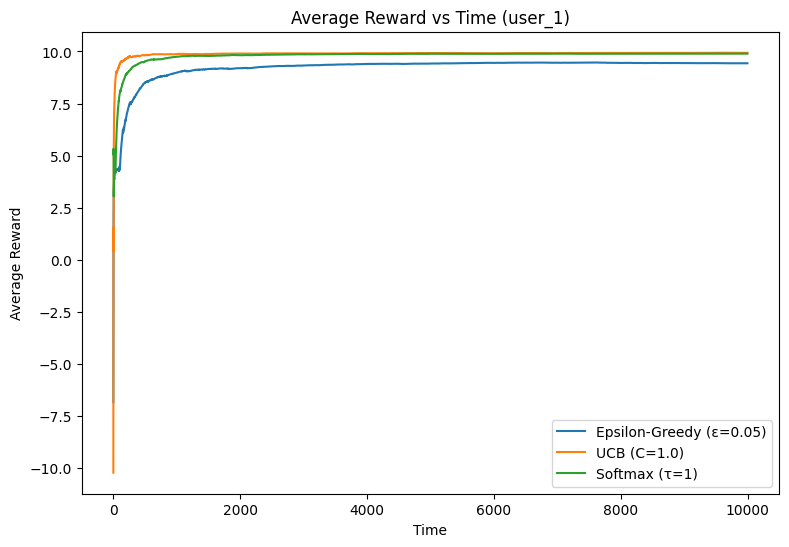

In [44]:
# -----------------------------------------
# Average Reward vs Time (All Algorithms)
# Example: user_1
# -----------------------------------------

ctx = "user_1"

plt.figure(figsize=(9, 6))

# Best epsilon-greedy
plt.plot(
    epsilon_results[ctx][0.05]["avg_rewards"],
    label="Epsilon-Greedy (ε=0.05)"
)

# Best UCB
plt.plot(
    ucb_results[ctx][1.0]["avg_rewards"],
    label="UCB (C=1.0)"
)

# Softmax
plt.plot(
    softmax_results[ctx]["avg_rewards"],
    label="Softmax (τ=1)"
)

plt.xlabel("Time")
plt.ylabel("Average Reward")
plt.title("Average Reward vs Time (user_1)")
plt.legend()
plt.show()


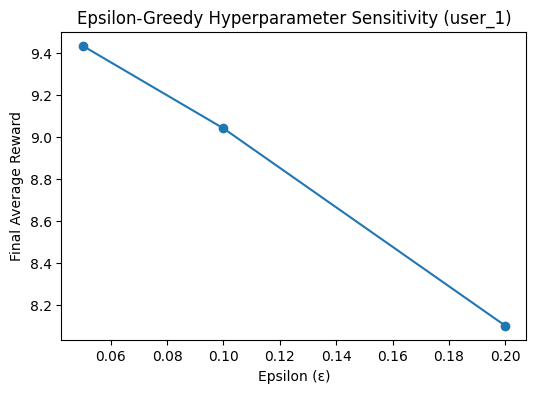

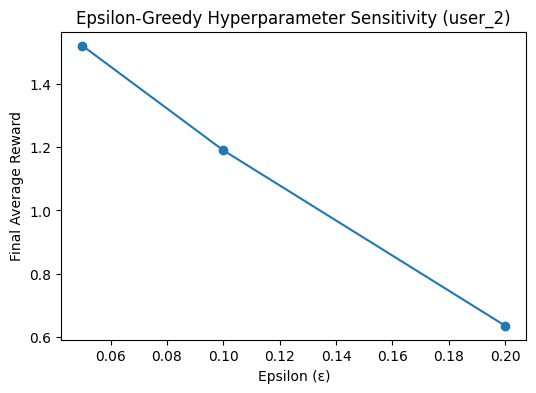

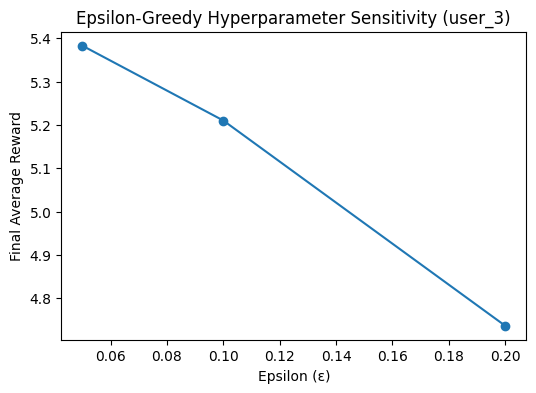

In [45]:
# -----------------------------------------
# Hyperparameter Comparison (Final Avg Reward)
# -----------------------------------------

contexts = CONTEXTS

for ctx in contexts:
    eps_vals = []
    eps_rewards = []

    for eps in EPSILONS:
        eps_vals.append(eps)
        eps_rewards.append(epsilon_results[ctx][eps]["avg_rewards"][-1])

    plt.figure(figsize=(6, 4))
    plt.plot(eps_vals, eps_rewards, marker="o")
    plt.xlabel("Epsilon (ε)")
    plt.ylabel("Final Average Reward")
    plt.title(f"Epsilon-Greedy Hyperparameter Sensitivity ({ctx})")
    plt.show()


I implemented a contextual bandit-based news recommendation system using three strategies: Epsilon-Greedy, Upper Confidence Bound (UCB),and Softmax. Users were first classified into one of three contexts using a supervised learning model. For each context, a separate bandit model was trained over four news categories.

Experimental results over a time horizon of T = 10,000 steps showed that UCB consistently achieved the highest average reward across all user contexts, followed by Softmax and Epsilon-Greedy. Lower values of ε in Epsilon-Greedy led to better performance, indicating that excessive exploration is suboptimal in this stationary environment. UCB demonstrated robustness to different values of the exploration parameter C.

Softmax with a fixed temperature τ = 1 achieved competitive performance by gradually reducing exploration as reward estimates stabilized. Overall, UCB provided the best balance between exploration and exploitation and was therefore selected for the final recommendation engine.

The end-to-end system successfully integrates user classification, contextual bandit decision-making, and article recommendation, demonstrating the effectiveness of contextual bandits for personalized news recommendation.